<div style="display:flex; align-items:flex-start; justify-content:space-between; gap:24px; border-bottom:3px solid #8f001a; padding-bottom:16px;">
  <div>
    <h1 style="margin-bottom:0.35em;">Exercise 9: Parallel Fan-Out for Multi-Timescale SPI Analysis</h1>
    <p style="font-size:1.05em; margin:0.2em 0;"><strong>Faculty of Engineering, University of Ottawa</strong></p>
    <p style="font-size:1.05em; margin:0.2em 0;"><strong>Provided By:</strong></p>
    <p style="font-size:1.05em; margin:0.2em 0;">Professor Hossein Bonakdari</p>
    <p style="font-size:1.05em; margin:0.2em 0;">PhD Candidate Mohammad Hashtari</p>
  </div>
  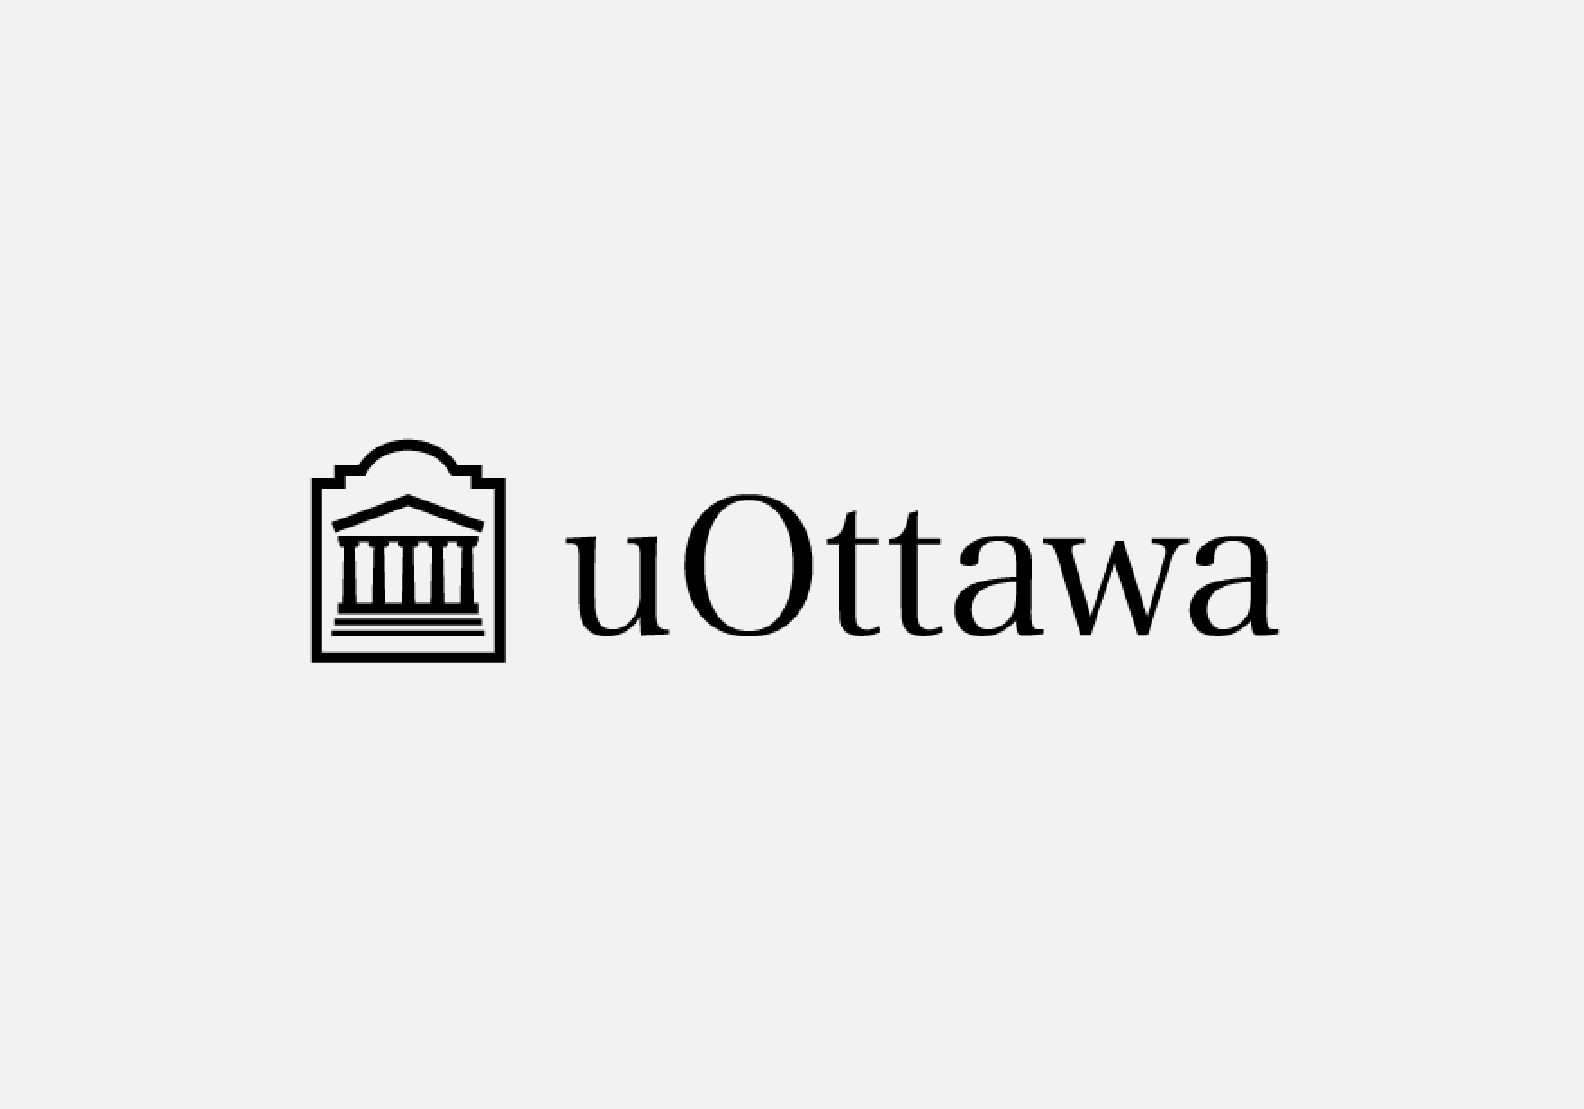
</div>

The final notebook runs the same SPI calculation at several accumulation windows, then combines the outputs in one comparison. The hydrology example compares SPI-1, SPI-3, SPI-6, and SPI-12 drought signals.

In [ ]:
# Browser package setup for JupyterLite. Safe to run in local Jupyter too.
import sys

if sys.platform == "emscripten":
    import piplite
    await piplite.install(["numpy", "pandas", "matplotlib", "scipy"])


## 1. Source Basis

The drought-index method is based on the original and operational SPI references:

- McKee, T. B., Doesken, N. J., and Kleist, J. (1993). *The relationship of drought frequency and duration to time scales*. Proceedings of the 8th Conference on Applied Climatology, American Meteorological Society, 179-184. https://www.droughtmanagement.info/literature/AMS_Relationship_Drought_Frequency_Duration_Time_Scales_1993.pdf
- Edwards, D. C., and McKee, T. B. (1997). *Characteristics of 20th century drought in the United States at multiple time scales*. Colorado State University, Climatology Report 97-2. https://mountainscholar.org/handle/10217/170176
- World Meteorological Organization. (2012). *Standardized Precipitation Index User Guide*. WMO-No. 1090. https://www.droughtmanagement.info/literature/WMO_standardized_precipitation_index_user_guide_en_2012.pdf

Scientific note: this notebook uses a short synthetic monthly record, so the SPI values are for teaching the calculation and interpretation. Operational SPI should use a longer climatological baseline, calendar-month stratification where appropriate, and careful treatment of zero precipitation.

## 2. Learning Goal

The parallel fan-out pattern is useful when configurations are independent:

1. Define one shared task and one shared dataset.
2. Assign one configuration to each worker.
3. Run configurations independently.
4. Collect compact result summaries.
5. Aggregate the summaries into one comparison table.

Hydrology target: compute drought-event summaries for SPI-1, SPI-3, SPI-6, and SPI-12.

## 3. Libraries

The notebook uses `numpy`, `pandas`, `matplotlib`, and `scipy.stats`.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from scipy.stats import gamma, norm

TIMESCALES = [1, 3, 6, 12]

plt.rcParams.update({
    "figure.figsize": (9, 4),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## 4. Monthly Precipitation Record

The synthetic 60-month precipitation record has repeated wet seasons and several dry periods. Values are monthly totals in millimetres.

In [ ]:
precip_mm = np.array([
    62, 45, 80, 120, 95, 110, 30, 15, 8, 42, 70, 88,
    55, 40, 75, 130, 100, 95, 20, 10, 5, 38, 65, 82,
    70, 50, 90, 140, 110, 105, 25, 12, 6, 40, 68, 90,
    48, 35, 68, 115, 88, 92, 18, 8, 4, 35, 60, 78,
    58, 42, 72, 125, 98, 100, 22, 11, 5, 37, 63, 85,
], dtype=float)

months = pd.date_range("2019-01-01", periods=len(precip_mm), freq="MS")
precip_df = pd.DataFrame({"month": months, "precipitation_mm": precip_mm})
precip_df.head()

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.bar(precip_df["month"], precip_df["precipitation_mm"], color="#0b7285")
ax.set_title("Synthetic Monthly Precipitation Record")
ax.set_xlabel("Month")
ax.set_ylabel("Precipitation (mm/month)")
plt.show()

## 5. Concept Graph

Each timescale can be analysed independently. The reporter only needs compact summaries from each branch.

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4.2))
ax.set_axis_off()

center_x = 0.12
worker_x = 0.44
reporter_x = 0.77
worker_ys = [0.78, 0.60, 0.42, 0.24]

def add_box(x, y, text, width=0.18, height=0.11, face="#edf6f9", fontsize=9.5):
    box = FancyBboxPatch(
        (x, y), width, height,
        boxstyle="round,pad=0.02,rounding_size=0.025",
        linewidth=1.2,
        edgecolor="#264653",
        facecolor=face,
        transform=ax.transAxes,
    )
    ax.add_patch(box)
    ax.text(x + width / 2, y + height / 2, text, ha="center", va="center", fontsize=fontsize, weight="bold", transform=ax.transAxes)

add_box(center_x, 0.46, "Parent\nOrchestrator", width=0.18, height=0.18)
for y, label in zip(worker_ys, ["SPI-1", "SPI-3", "SPI-6", "SPI-12"]):
    add_box(worker_x, y, label, width=0.15, height=0.10)
    ax.annotate("", xy=(worker_x, y + 0.05), xytext=(center_x + 0.18, 0.55), arrowprops={"arrowstyle": "->", "lw": 1.2, "color": "#264653"}, xycoords=ax.transAxes)
    ax.annotate("", xy=(reporter_x, 0.55), xytext=(worker_x + 0.15, y + 0.05), arrowprops={"arrowstyle": "->", "lw": 1.2, "color": "#264653"}, xycoords=ax.transAxes)

add_box(reporter_x, 0.46, "Reporter\nSummary", width=0.18, height=0.18, face="#fff4e6")
ax.set_title("Parallel Fan-Out Pattern", pad=10)
plt.show()

## 6. Before and After Prompts

Sequential prompt:

```text
Compute SPI-1, SPI-3, SPI-6, and SPI-12 and summarize drought periods.
```

Fan-out prompt:

```text
Run four independent analyses in parallel, one per SPI timescale.
Each worker receives the same precipitation record and one timescale only.
Each worker returns drought event count, longest duration, minimum SPI, and month of minimum SPI.
A reporter then aggregates the four summaries into one comparison table and interpretation.
```

The second prompt separates independent computation from final synthesis.

## 7. SPI Implementation

This simplified implementation aggregates precipitation over a rolling window, fits a Gamma distribution to positive aggregated totals, then transforms cumulative probabilities to standard normal values.

In [ ]:
def rolling_sum(values, window):
    values = np.asarray(values, dtype=float)
    return np.convolve(values, np.ones(window), mode="valid")


def compute_spi(precipitation, timescale):
    """Compute a simplified Gamma-based SPI for monthly precipitation totals."""
    if timescale < 1:
        raise ValueError("timescale must be at least 1 month")

    precipitation = np.asarray(precipitation, dtype=float)
    if precipitation.size < timescale + 1:
        raise ValueError("record is too short for the requested timescale")
    if np.any(precipitation < 0):
        raise ValueError("precipitation cannot be negative")

    aggregated = rolling_sum(precipitation, timescale)
    if np.all(aggregated == 0):
        raise ValueError("all aggregated precipitation totals are zero")

    positive = aggregated[aggregated > 0]
    zero_probability = 1.0 - (len(positive) / len(aggregated))

    if len(positive) < 2 or np.isclose(np.std(positive), 0.0):
        std = np.std(aggregated, ddof=1)
        return np.zeros_like(aggregated) if std == 0 else (aggregated - np.mean(aggregated)) / std

    shape, loc, scale = gamma.fit(positive, floc=0)
    probabilities = []
    for value in aggregated:
        if value <= 0:
            probability = max(zero_probability / 2, 1e-6)
        else:
            probability = zero_probability + (1.0 - zero_probability) * gamma.cdf(value, shape, loc=loc, scale=scale)
        probabilities.append(np.clip(probability, 1e-6, 1 - 1e-6))

    return norm.ppf(probabilities)


spi3 = compute_spi(precip_mm, 3)
spi3[:5]

## 8. Worker and Reporter Functions

Each worker receives one timescale and returns only a compact summary. The reporter aggregates summaries without recomputing the full SPI arrays.

In [ ]:
def drought_events(spi_values, end_month_indices, threshold=-1.0):
    events = []
    current_start = None
    current_values = []

    for value, month_index in zip(spi_values, end_month_indices):
        if value < threshold:
            if current_start is None:
                current_start = month_index
            current_values.append(value)
        elif current_start is not None:
            events.append({
                "start_month": current_start,
                "end_month": month_index - 1,
                "duration_months": len(current_values),
                "minimum_spi": float(np.min(current_values)),
            })
            current_start = None
            current_values = []

    if current_start is not None:
        events.append({
            "start_month": current_start,
            "end_month": int(end_month_indices[-1]),
            "duration_months": len(current_values),
            "minimum_spi": float(np.min(current_values)),
        })

    return events


def analyze_spi_timescale(precipitation, timescale):
    spi = compute_spi(precipitation, timescale)
    end_month_indices = np.arange(timescale, len(precipitation) + 1)
    events = drought_events(spi, end_month_indices)
    min_position = int(np.argmin(spi))
    longest = max((event["duration_months"] for event in events), default=0)

    return {
        "timescale": f"SPI-{timescale}",
        "drought_events": len(events),
        "longest_duration_months": longest,
        "minimum_spi": float(spi[min_position]),
        "month_of_minimum_spi": int(end_month_indices[min_position]),
        "spi_values": spi,
        "end_month_indices": end_month_indices,
        "events": events,
    }


worker_result = analyze_spi_timescale(precip_mm, 3)
{key: worker_result[key] for key in ["timescale", "drought_events", "longest_duration_months", "minimum_spi", "month_of_minimum_spi"]}

## 9. Simulated Parallel Fan-Out

In a real multi-agent system these workers would run concurrently. In this notebook, they are executed in a compact loop so the result is reproducible.

In [ ]:
fanout_results = [analyze_spi_timescale(precip_mm, timescale) for timescale in TIMESCALES]

report_table = pd.DataFrame([
    {
        "Timescale": result["timescale"],
        "Drought Events": result["drought_events"],
        "Longest Duration": result["longest_duration_months"],
        "Min SPI": result["minimum_spi"],
        "Month of Min SPI": result["month_of_minimum_spi"],
    }
    for result in fanout_results
])

report_table

## 10. Verification Tests

These checks confirm output length, finite values, scale invariance, and expected short- versus long-timescale behaviour.

In [ ]:
assert len(compute_spi(precip_mm, 1)) == len(precip_mm)
assert len(compute_spi(precip_mm, 3)) == len(precip_mm) - 3 + 1
assert len(compute_spi(precip_mm, 12)) == len(precip_mm) - 12 + 1
assert np.all(np.isfinite(compute_spi(precip_mm, 3)))
assert np.all((-4.0 <= compute_spi(precip_mm, 3)) & (compute_spi(precip_mm, 3) <= 4.0))
assert abs(np.mean(compute_spi(precip_mm, 1))) < 0.5
assert np.std(compute_spi(precip_mm, 1), ddof=1) > np.std(compute_spi(precip_mm, 12), ddof=1)
assert np.allclose(compute_spi(precip_mm, 3), compute_spi(precip_mm * 10, 3), atol=0.05)

try:
    compute_spi([50.0, 60.0, 70.0], timescale=5)
    raise AssertionError("short records should fail")
except ValueError:
    pass

try:
    compute_spi(precip_mm, timescale=0)
    raise AssertionError("zero timescale should fail")
except ValueError:
    pass

print("All SPI fan-out checks passed.")

## 11. Multi-Timescale SPI View

Short timescales respond quickly to monthly deficits. Longer timescales smooth short deficits and emphasize persistent precipitation shortage.

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(9, 8), sharex=True, sharey=True)

for ax, result in zip(axes, fanout_results):
    dates = months[result["end_month_indices"] - 1]
    ax.plot(dates, result["spi_values"], color="#0b7285", linewidth=1.4)
    ax.axhline(-1.0, color="#d9480f", linestyle="--", linewidth=1)
    ax.axhline(0.0, color="#222222", linewidth=0.8)
    ax.set_ylabel(result["timescale"])

axes[0].set_title("SPI Across Timescales")
axes[-1].set_xlabel("Month")
fig.text(0.02, 0.5, "SPI", va="center", rotation="vertical")
plt.tight_layout(rect=(0.04, 0.02, 1, 0.98))
plt.show()

## 12. Reporter Summary

The reporter receives the four compact summaries and writes the comparison.

In [ ]:
short_term_min = report_table.loc[report_table["Timescale"].isin(["SPI-1", "SPI-3"]), "Min SPI"].min()
long_term_min = report_table.loc[report_table["Timescale"].isin(["SPI-6", "SPI-12"]), "Min SPI"].min()

interpretation = (
    f"Short-timescale SPI captures sharper monthly to seasonal drought signals, with minimum SPI {short_term_min:.2f}. "
    f"Longer-timescale SPI smooths the same precipitation deficits and is more relevant to accumulated storage, streamflow, and reservoir-management concerns, with minimum SPI {long_term_min:.2f}."
)

print(report_table.to_markdown(index=False))
print()
print(interpretation)

## 13. Hydrological Interpretation

SPI timescale controls the process being emphasized. SPI-1 and SPI-3 are more sensitive to short precipitation deficits that can affect soil moisture and near-term agricultural stress. SPI-6 and SPI-12 emphasize accumulated deficits that are more relevant to streamflow, reservoir storage, and groundwater response. A water manager should not treat all SPI timescales as interchangeable evidence.

## 14. Summary

- Parallel fan-out is appropriate when configurations are independent.
- Each SPI timescale can be analysed separately, then summarized by a reporter.
- Short-timescale SPI is more volatile; long-timescale SPI is smoother and more storage-relevant.
- The final report should compare compact drought summaries rather than mixing all intermediate arrays.
- Operational SPI requires a longer climatological baseline than this synthetic teaching record.